# MACHINE LEARNING (ML)

Explicação sobre o que está sendo desenvolvido...

In [221]:
# Bibliotecas que serão utilizadas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [222]:
# Carregamento da base de dados
df = pd.read_csv("vendas_aguas_LGPD_tratada.csv", delimiter=";")

df.head()

,id_cliente,dt_entrega,dt_semana,qtd_aguas_entregues,qtd_aguas_ticket,obs_pedido,dt_estacao,dt_ano,dt_mes,cli_dias_desde_ultimo_pedido,cli_intervalo_medio,cli_frequencia_pedidos,cli_media_aguas_por_pedido,cli_total_pedidos,target_dt_proxima_compra,target_dias_ate_recompra,target_vai_comprar_15d
0,89,2023-01-02,Segunda,1,03/03,NaN,Verão,2023.0,1.0,0,5.91,1,1.01,1,2023-01-11,9,1
1,102,2023-01-02,Segunda,1,0,NaN,Verão,2023.0,1.0,0,NaN,1,1.00,1,NaN,0,0
2,120,2023-01-02,Segunda,2,0,NaN,Verão,2023.0,1.0,0,14.07,1,1.93,1,2023-01-18,16,0
3,50,2023-01-02,Segunda,2,0,NaN,Verão,2023.0,1.0,0,7.80,1,2.03,1,2023-01-09,7,1
4,8,2023-01-02,Segunda,1,07/10,NaN,Verão,2023.0,1.0,0,6.15,1,1.00,1,2023-01-06,4,1


## 1º - Tratamento da base de dados para ML

Após a EDA, está sendo realizado tratamentos específicos para adequar as variáveis ao formato necessário para a modelagem, preservando as informações relevantes e evitando problemas que possam comprometer o treinamento do modelo. As etapas incluem a transformação de variáveis categóricas, tratamento de valores ausentes, remoção de informações futuras que poderiam causar Data Leakage (Vazamento de dados) e eliminação de variáveis redundantes. INSEIR A F) QUE FOI REALIZADA...

In [223]:
df_ml = df.copy()

### A) Transformação das variáveis "obs_pedido" e "dt_estacao" em binário

In [224]:
# Verificação das variáveis
df_ml[['obs_pedido', 'dt_estacao']].head()

,obs_pedido,dt_estacao
0,NaN,Verão
1,NaN,Verão
2,NaN,Verão
3,NaN,Verão
4,NaN,Verão


In [225]:
# Transformação de valores nulos da variável "obs_pedido" para 0 e valores não nulos para 1
df_ml['obs_pedido'] = df_ml['obs_pedido'].notnull().astype(int)

# Transformação de valores nulos da variável "dt_estacao" para 0 = inverno e 1 = verão
df_ml['dt_estacao'] = df_ml['dt_estacao'].map({'Inverno': 0, 'Verão': 1})

In [226]:
# Conferência da transformação
obs = df_ml['obs_pedido'].unique()
estacao = df_ml['dt_estacao'].unique()

print(f'Valores únicos da variável "obs_pedido": {obs}')
print(f'Valores únicos da variável "dt_estacao": {estacao}')

Valores únicos da variável "obs_pedido": [0 1]
Valores únicos da variável "dt_estacao": [1 0]


In [227]:
# Conferência da variável
df_ml[['obs_pedido', 'dt_estacao']].head()

,obs_pedido,dt_estacao
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


### B) Transformação da variável "dt_semana" com One-Hot Encoding

In [228]:
# Verificação dos dados da variável
df_ml['dt_semana'].unique()

array(['Segunda', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Terça',
       'Segunda ', 'Domingo'], dtype=object)

In [229]:
# Limpeza de dados (como espaços em branco antes e depois do texto)
df_ml['dt_semana'] = df_ml['dt_semana'].str.strip()

In [230]:
# Aplicação do One-Hot Encoding e remoção da coluna original
df_ml = pd.get_dummies(df_ml, columns=['dt_semana'], dtype=int)

In [231]:
# Conferência da aplicação do One-Hot Encoding e exibição de todo dataframe
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', None)  

df_ml.head()

,id_cliente,dt_entrega,qtd_aguas_entregues,qtd_aguas_ticket,obs_pedido,dt_estacao,dt_ano,dt_mes,cli_dias_desde_ultimo_pedido,cli_intervalo_medio,cli_frequencia_pedidos,cli_media_aguas_por_pedido,cli_total_pedidos,target_dt_proxima_compra,target_dias_ate_recompra,target_vai_comprar_15d,dt_semana_Domingo,dt_semana_Quarta,dt_semana_Quinta,dt_semana_Segunda,dt_semana_Sexta,dt_semana_Sábado,dt_semana_Terça
0,89,2023-01-02,1,03/03,0,1,2023.0,1.0,0,5.91,1,1.01,1,2023-01-11,9,1,0,0,0,1,0,0,0
1,102,2023-01-02,1,0,0,1,2023.0,1.0,0,NaN,1,1.00,1,NaN,0,0,0,0,0,1,0,0,0
2,120,2023-01-02,2,0,0,1,2023.0,1.0,0,14.07,1,1.93,1,2023-01-18,16,0,0,0,0,1,0,0,0
3,50,2023-01-02,2,0,0,1,2023.0,1.0,0,7.80,1,2.03,1,2023-01-09,7,1,0,0,0,1,0,0,0
4,8,2023-01-02,1,07/10,0,1,2023.0,1.0,0,6.15,1,1.00,1,2023-01-06,4,1,0,0,0,1,0,0,0


### C) Imputar a mediana para a variável "cli_intervalo_medio" com valores faltantes

In [232]:
# Verificação da quantidade de valores faltantes
df_ml['cli_intervalo_medio'].isnull().sum()

np.int64(53)

In [233]:
# Calcular a mediana da variável
mediana = df_ml['cli_intervalo_medio'].median()

# Substituir os valores faltantes pela mediana
df_ml['cli_intervalo_medio'].fillna(mediana, inplace=True)

C:\Users\nneto\AppData\Local\Temp\ipykernel_18580\3129123636.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['cli_intervalo_medio'].fillna(mediana, inplace=True)


In [234]:
# Conferência da substituição dos valores faltantes
df_ml['cli_intervalo_medio'].isnull().sum()

np.int64(0)

### D) Exclusão das variáveis "target_dt_proxima_compra" e "target_dias_ate_recompra"

In [235]:
# Exclusão das variáveis alvo do modelo de machine learning, pois causarão Data Leakage
df_ml = df_ml.drop(['target_dt_proxima_compra', 'target_dias_ate_recompra'], axis=1)

In [236]:
# Conferência da exclusão das variáveis alvo
df_ml.head()

,id_cliente,dt_entrega,qtd_aguas_entregues,qtd_aguas_ticket,obs_pedido,dt_estacao,dt_ano,dt_mes,cli_dias_desde_ultimo_pedido,cli_intervalo_medio,cli_frequencia_pedidos,cli_media_aguas_por_pedido,cli_total_pedidos,target_vai_comprar_15d,dt_semana_Domingo,dt_semana_Quarta,dt_semana_Quinta,dt_semana_Segunda,dt_semana_Sexta,dt_semana_Sábado,dt_semana_Terça
0,89,2023-01-02,1,03/03,0,1,2023.0,1.0,0,5.91,1,1.01,1,1,0,0,0,1,0,0,0
1,102,2023-01-02,1,0,0,1,2023.0,1.0,0,10.01,1,1.00,1,0,0,0,0,1,0,0,0
2,120,2023-01-02,2,0,0,1,2023.0,1.0,0,14.07,1,1.93,1,0,0,0,0,1,0,0,0
3,50,2023-01-02,2,0,0,1,2023.0,1.0,0,7.80,1,2.03,1,1,0,0,0,1,0,0,0
4,8,2023-01-02,1,07/10,0,1,2023.0,1.0,0,6.15,1,1.00,1,1,0,0,0,1,0,0,0


### E) Exclusão da variável "cli_frequencia_pedidos"

In [237]:
# Exclusão da variável
df_ml = df_ml.drop(['cli_frequencia_pedidos'], axis=1)

In [238]:
# Conferência da exclusão da variável
df_ml.head()

,id_cliente,dt_entrega,qtd_aguas_entregues,qtd_aguas_ticket,obs_pedido,dt_estacao,dt_ano,dt_mes,cli_dias_desde_ultimo_pedido,cli_intervalo_medio,cli_media_aguas_por_pedido,cli_total_pedidos,target_vai_comprar_15d,dt_semana_Domingo,dt_semana_Quarta,dt_semana_Quinta,dt_semana_Segunda,dt_semana_Sexta,dt_semana_Sábado,dt_semana_Terça
0,89,2023-01-02,1,03/03,0,1,2023.0,1.0,0,5.91,1.01,1,1,0,0,0,1,0,0,0
1,102,2023-01-02,1,0,0,1,2023.0,1.0,0,10.01,1.00,1,0,0,0,0,1,0,0,0
2,120,2023-01-02,2,0,0,1,2023.0,1.0,0,14.07,1.93,1,0,0,0,0,1,0,0,0
3,50,2023-01-02,2,0,0,1,2023.0,1.0,0,7.80,2.03,1,1,0,0,0,1,0,0,0
4,8,2023-01-02,1,07/10,0,1,2023.0,1.0,0,6.15,1.00,1,1,0,0,0,1,0,0,0


### F) Transformação da variável "qtd_aguas_ticket" em registros válidos

In [239]:
# Verificação dos dados presente na variável
df_ml['qtd_aguas_ticket'].unique()

array(['03/03', '0', '07/10', '10/10', '11/15', '08/10', '15/04', '09/10',
       '02/05', '01/10', '02/15', '01/03', '02/03', '02/10', '04/10',
       '05/10', '03/10', '06/10', '15', '04/15', '06/15', '08/15',
       '10/15', '14/15', '04/16', '18', '02/18', '1', '02/08', '3',
       '02/16', '16', '01/15', '05/15', '11', '14', '12/15', '06/11',
       '03/16', '07/11', '07/16', '08/11', '07/15', '09/15', '01/12',
       '10', '13/15', '01/02', '11/05', '5', '02/02', '03/15', '2', '7',
       '8', '9', '02/04'], dtype=object)

In [242]:
# Conversão da variável "qtd_aguas_ticket" para o formato numérico
def extrair_ticket(valor):
    if pd.isna(valor):
        return pd.Series([None, None, None, 0])

    valor = str(valor).strip()

    if '/' not in valor:
        return pd.Series([None, None, None, 0])

    partes = valor.split('/')

    if len(partes) != 2:
        return pd.Series([None, None, None, 0])

    try:
        usados = int(partes[0])
        total = int(partes[1])

        if total == 0 or usados > total:
            return pd.Series([None, None, None, 0])

        percentual = usados / total

        return pd.Series([usados, total, percentual, 1])

    except ValueError:
        return pd.Series([None, None, None, 0])

# Aplicação da função para extrair os valores da variável "qtd_aguas_ticket"
df_ml[
    ['ticket_usados',
     'ticket_total',
     'ticket_percentual_uso',
     'ticket_formato_valido']
] = df_ml['qtd_aguas_ticket'].apply(extrair_ticket)

# Substituição de valores faltantes por 0
df_ml['ticket_usados'].fillna(0, inplace=True)
df_ml['ticket_total'].fillna(0, inplace=True)
df_ml['ticket_percentual_uso'].fillna(0, inplace=True)

C:\Users\nneto\AppData\Local\Temp\ipykernel_18580\2684319767.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['ticket_usados'].fillna(0, inplace=True)
C:\Users\nneto\AppData\Local\Temp\ipykernel_18580\2684319767.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [243]:
# Conferência das variáveis após a aplicação da função
df_ml.head()

,id_cliente,dt_entrega,qtd_aguas_entregues,qtd_aguas_ticket,obs_pedido,dt_estacao,dt_ano,dt_mes,cli_dias_desde_ultimo_pedido,cli_intervalo_medio,cli_media_aguas_por_pedido,cli_total_pedidos,target_vai_comprar_15d,dt_semana_Domingo,dt_semana_Quarta,dt_semana_Quinta,dt_semana_Segunda,dt_semana_Sexta,dt_semana_Sábado,dt_semana_Terça,ticket_usados,ticket_total,ticket_percentual_uso,ticket_formato_valido
0,89,2023-01-02,1,03/03,0,1,2023.0,1.0,0,5.91,1.01,1,1,0,0,0,1,0,0,0,3.0,3.0,1.0,1.0
1,102,2023-01-02,1,0,0,1,2023.0,1.0,0,10.01,1.00,1,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0
2,120,2023-01-02,2,0,0,1,2023.0,1.0,0,14.07,1.93,1,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0
3,50,2023-01-02,2,0,0,1,2023.0,1.0,0,7.80,2.03,1,1,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0
4,8,2023-01-02,1,07/10,0,1,2023.0,1.0,0,6.15,1.00,1,1,0,0,0,1,0,0,0,7.0,10.0,0.7,1.0


## 2º - Duelo entre modelos: Regressão Linear x Árvore de Decisão x Random Forest

EXPLICAÇÃO DO POR QUE DESSES MODELOS...

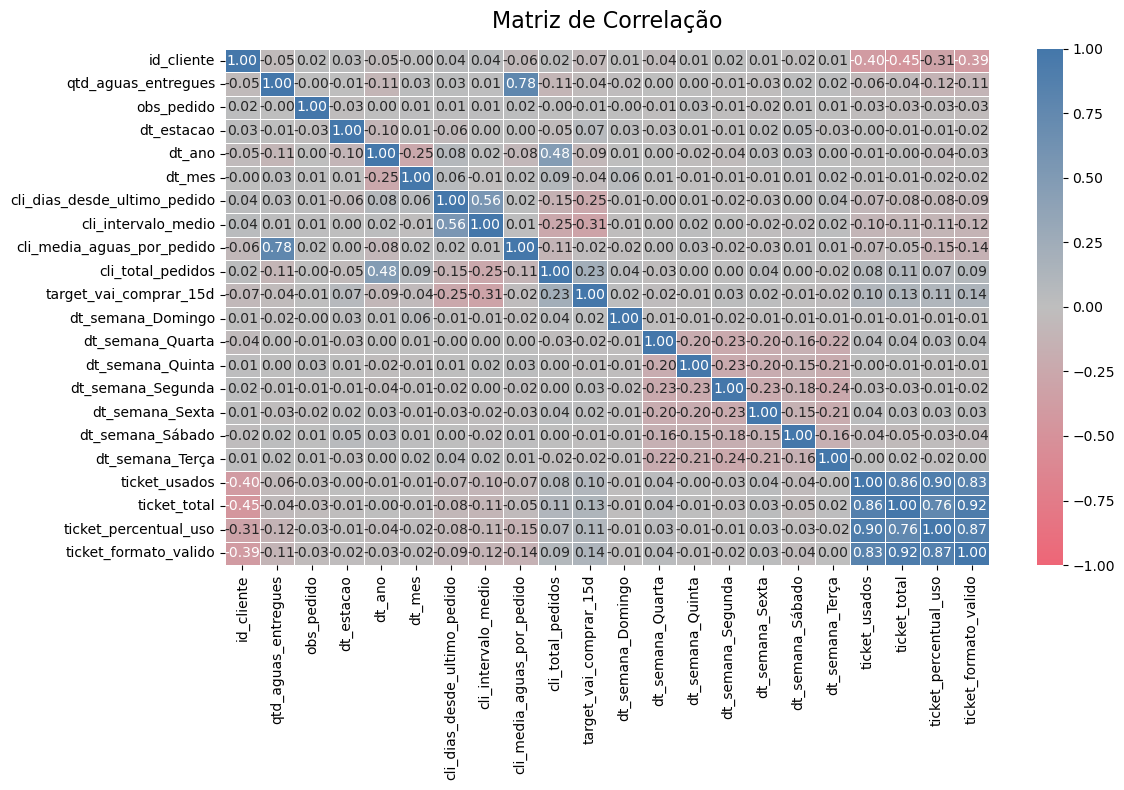

In [245]:
# Paleta de cores padrão do projeto
PALETA = {
    "azul": "#4477AA",
    "vermelho": "#EE6677",
    "verde": "#228833",
    "roxo": "#AA3377",
    "amarelo": "#C8A600",
    "cinza": "#BEBEBE",
    "preto": "#000000"
}

# Mapa de cores personalizado
cmap = LinearSegmentedColormap.from_list(
    "custom_cmap", 
    [PALETA["vermelho"], PALETA["cinza"], PALETA["azul"]]
)

# Variáveis apenas númericas para o cálculo da matriz de correlação
df_numerico = df_ml.select_dtypes(include=['number'])

# Calculo da matriz de correlação
matriz_corr = df_numerico.corr()

# Configuração do tamanho da figura
plt.figure(figsize=(12, 8))

# Mapa de calor
sns.heatmap(
    matriz_corr, 
    annot=True, 
    fmt=".2f", 
    cmap=cmap, 
    vmin=-1,
    vmax=1, 
    linewidths=0.5
)

# Título e ajuste do layout
plt.title("Matriz de Correlação", fontsize=16, pad=15)
plt.tight_layout()

# Exibição do gráfico
plt.show()

### A) Separação de X (variável de entrada) e y (variável de saída)

In [ ]:
X = df_ml.drop(['target_dias_ate_recompra', 'id_cliente', 'target_vai_comprar_15d', 'dt_entrega', ''])
y = df_ml['target_dias_ate_recompra']